# Día 1: clasificación de `dedo` con visión clásica

## Objetivo

En este cuaderno vais a construir una primera solución clásica para decidir si la postura de un `dedo` es correcta (`si`) o incorrecta (`no`).

La idea no es replicar una receta exacta, sino explorar varias herramientas de visión por computador y combinarlas en un pipeline razonable.

Al terminar, deberíais tener:

- una forma clara de cargar y recorrer el dataset;
- una estrategia de preprocesado que os ayude a estabilizar la imagen (recortar, normalizar, etc.);
- una regla final de decisión, aunque sea simple;
- una evaluación básica sobre un conjunto de test.

## Qué podéis intentar

No tenéis que seguir un único camino. Algunas posibilidades razonables son:

- trabajar con la imagen completa o recortar primero la zona útil;
- usar escala de grises, HSV, YCrCb o combinar varios espacios de color para detectar las regiones de interés;
- segmentar con umbrales fijos, histogramas, morfología o contornos;
- detectar primero el panel oscuro, la zona iluminada o directamente la mano;
- usar rasgos geométricos como área, caja, orientación, posición relativa o distancia a bordes;
- terminar con una regla heurística simple de clasificación en vez de un modelo aprendido.

## Instalación

```bash
pip install --upgrade numpy scipy pandas matplotlib pillow opencv-python scikit-learn seaborn
```

## Importaciones

In [15]:
# Escribe aquí las importaciones que vayas necesitando.
from pathlib import Path
import colorsys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
from sklearn.cluster import KMeans
import random
from sklearn.model_selection import train_test_split
import math
import matplotlib.pyplot as plt


## Configuración general

Define aquí las rutas y constantes que quieras reutilizar.

Sugerencias:

- carpeta del dataset `data/dedo`;
- semilla aleatoria;
- tamaño de test;
- umbrales o tamaños de kernels si decides usarlos.

In [7]:
# Configura aquí tu experimento.
DATA_DIR = Path("/home/manel31/Escritorio/cursoIA/dedo")

# Carpetas/clases dentro del dataset
CLASSES = ["si", "no"]

# Semilla para resultados reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Tamaño para test: 20%
TEST_SIZE = 0.2

# Extensiones de imagen aceptadas
IMG_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp"]


## Cargar el dataset

Empieza creando una tabla con al menos estas columnas:

- ruta de la imagen;
- etiqueta real (`si` o `no`);
- nombre de archivo;
- cualquier metadato adicional que te pueda resultar útil.

Preguntas guía:

- ¿Cuántas imágenes hay por clase?
- ¿Las clases están equilibradas?
- ¿Hay imágenes especialmente raras o difíciles?

In [8]:
# Recorre aquí la carpeta data/dedo y crea un DataFrame.
filas = []

for clase in CLASSES:
    carpeta = DATA_DIR / clase
    
    for img_path in carpeta.iterdir():
        if img_path.suffix.lower() in IMG_EXTENSIONS:
            filas.append({
                "ruta": str(img_path),
                "etiqueta": clase,
                "archivo": img_path.name,
                "extension": img_path.suffix.lower()
            })

df = pd.DataFrame(filas)

df.head()

,ruta,etiqueta,archivo,extension
0,/home/manel31/Escritorio/cursoIA/dedo/si/img_1...,si,img_1776864638561.png,.png
1,/home/manel31/Escritorio/cursoIA/dedo/si/img_1...,si,img_1777028523315.png,.png
2,/home/manel31/Escritorio/cursoIA/dedo/si/img_1...,si,img_1776863543984.png,.png
3,/home/manel31/Escritorio/cursoIA/dedo/si/img_1...,si,img_1776940791703.png,.png
4,/home/manel31/Escritorio/cursoIA/dedo/si/img_1...,si,img_1776864617064.png,.png


In [9]:
# Resume aquí el número de imágenes por clase.
resumen = df["etiqueta"].value_counts()

print("Número de imágenes por clase:")
print(resumen)

print("\nTotal de imágenes:", len(df))

Número de imágenes por clase:
etiqueta
si    44
no    37
Name: count, dtype: int64

Total de imágenes: 81


## Separación train/test

Reserva un conjunto de test reproducible. Aunque hoy no entrenéis una red, sí conviene dejar una evaluación separada del desarrollo.

In [12]:
# Haz aquí un train_test_split REPRODUCIBLE.
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["etiqueta"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))

print("\nTrain por clase:")
print(train_df["etiqueta"].value_counts())

print("\nTest por clase:")
print(test_df["etiqueta"].value_counts())

Train: 64
Test: 17

Train por clase:
etiqueta
si    35
no    29
Name: count, dtype: int64

Test por clase:
etiqueta
si    9
no    8
Name: count, dtype: int64


## Exploración visual inicial

Antes de programar reglas, mirad ejemplos.

Qué merece la pena observar:

- iluminación global;
- posición del panel negro;
- orientación de la mano o del brazo;
- forma y posición de la zona luminosa;
- diferencias visuales entre ejemplos `si` y `no`.

In [13]:
def leer_imagen(ruta):
    """Lee una imagen con OpenCV. Devuelve None si no se puede leer."""
    img = cv2.imread(str(ruta))
    return img 

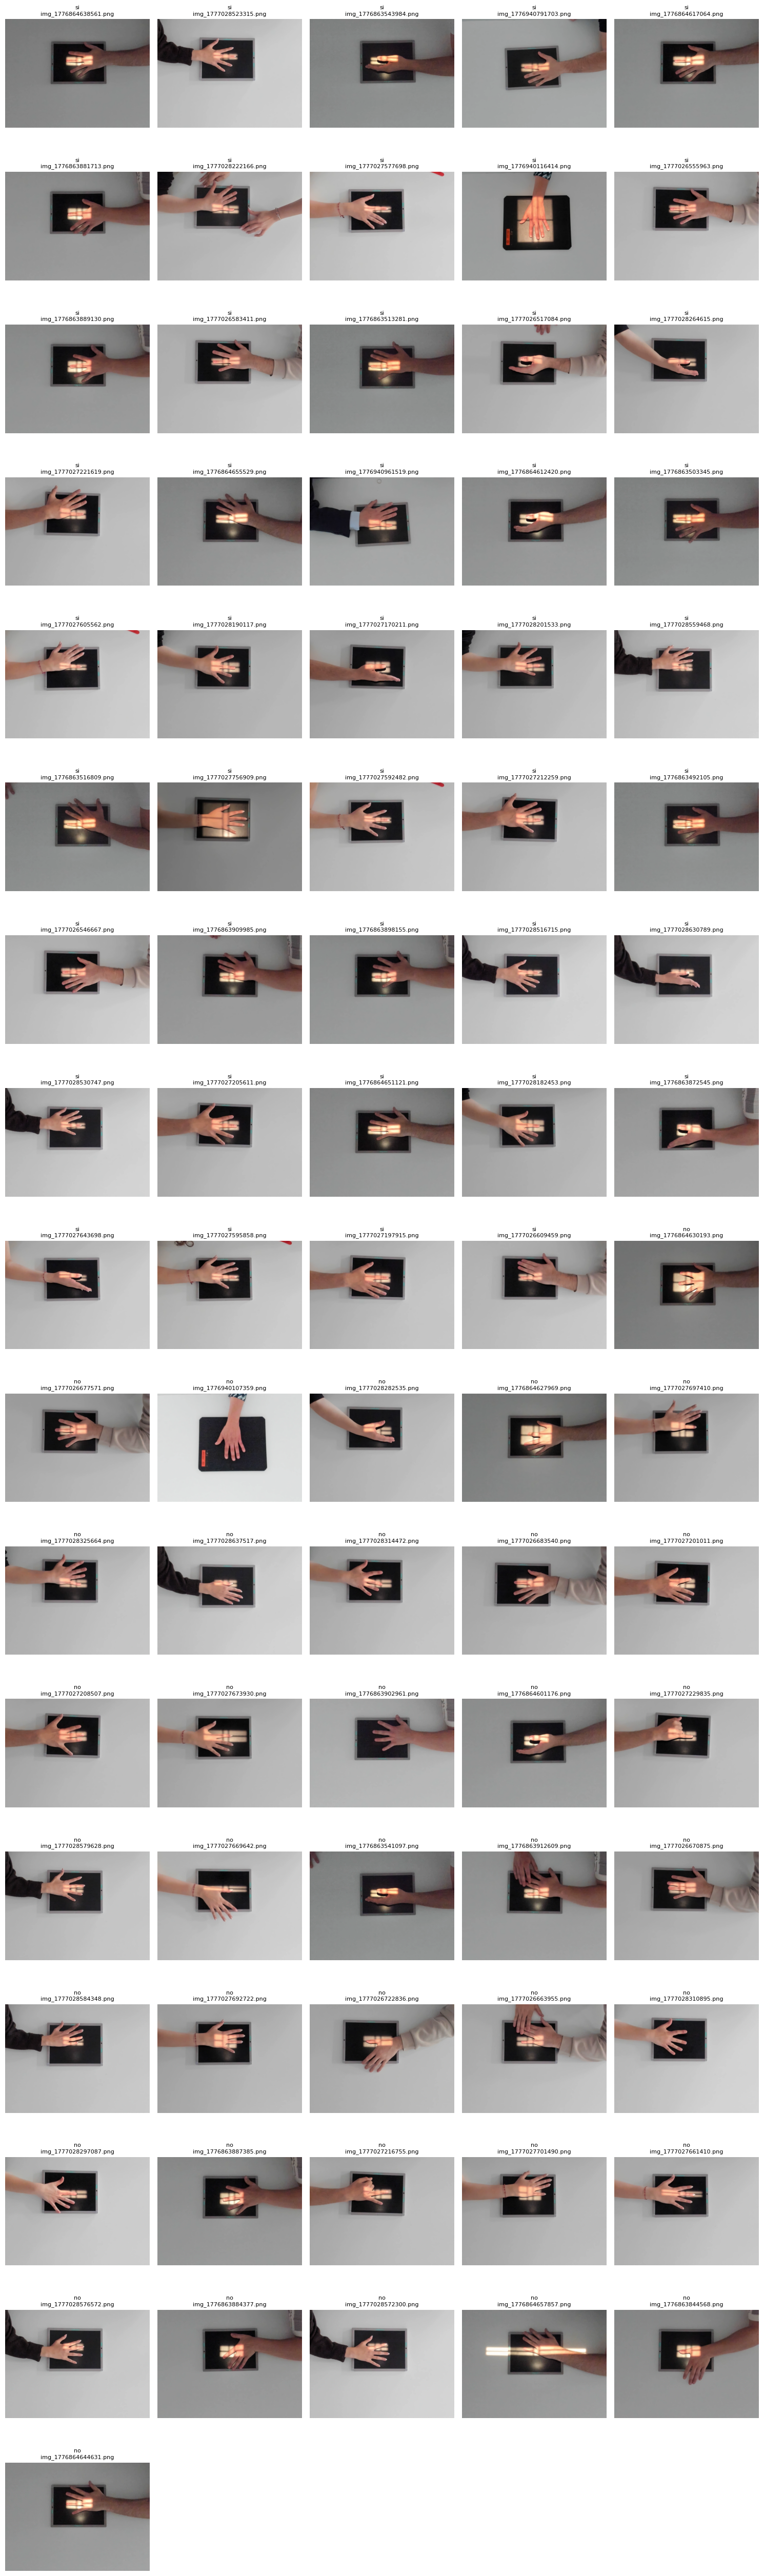

In [16]:
# Muestra aquí una rejilla de imágenes del dataset.
imagenes_validas = []

for _, row in df.iterrows():
    img = leer_imagen(row["ruta"])

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imagenes_validas.append((img, row["etiqueta"], row["archivo"]))
    else:
        print("No se pudo leer:", row["ruta"])

n = len(imagenes_validas)
columnas = 5
filas = math.ceil(n / columnas)

plt.figure(figsize=(15, filas * 3))

for i, (img, etiqueta, archivo) in enumerate(imagenes_validas):
    plt.subplot(filas, columnas, i + 1)
    plt.imshow(img)
    plt.title(f"{etiqueta}\n{archivo}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Propuesta para el pipeline

Estas figuras muestran algunas operaciones que podrían ser útiles. No son instrucciones obligatorias, solo ejemplos de qué tipo de etapas podéis construir.

### Posible etapa 1: normalización y detección del panel

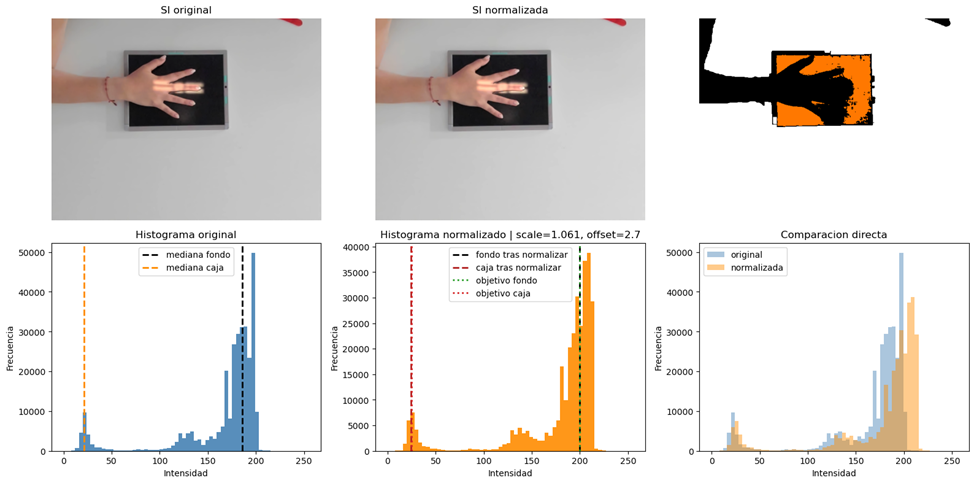

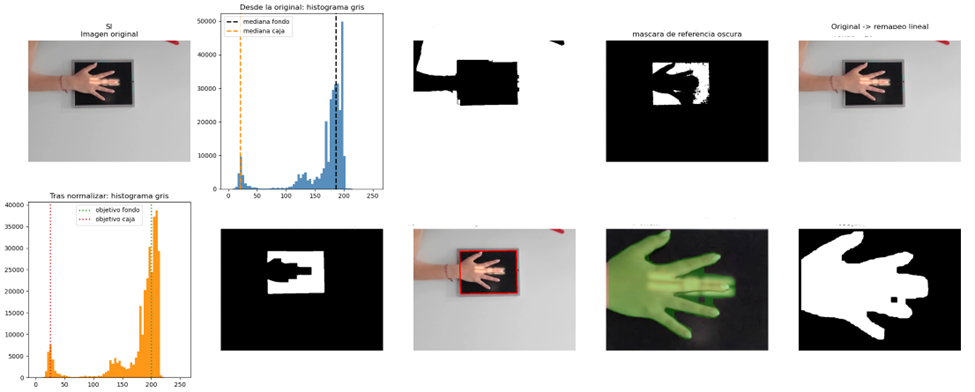

## Diseñar vuestro preprocesado

En esta parte debéis decidir qué transformar primero y por qué.

Opciones posibles:

- suavizado;
- normalización de brillo;
- umbralización;
- operaciones morfológicas;
- contornos;
- recorte o `warpPerspective`;
- reorientación de la mano.

Es recomendable que visualicéis la salida de cada operación antes de seguir.

In [17]:
# Implementa aquí una primera etapa de preprocesado.
def preprocesar_imagen(ruta):
    img = leer_imagen(ruta)

    if img is None:
        return None

    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Suavizado para reducir ruido
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # Normalización de contraste local
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    norm = clahe.apply(blur)

    # Umbralización para detectar zonas muy luminosas
    _, mask = cv2.threshold(norm, 200, 255, cv2.THRESH_BINARY)

    # Limpiar ruido
    kernel = np.ones((5, 5), np.uint8)
    mask_limpia = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask_limpia = cv2.morphologyEx(mask_limpia, cv2.MORPH_CLOSE, kernel)

    # Contornos de las zonas luminosas
    contornos, _ = cv2.findContours(mask_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    return {
        "original": img,
        "gray": gray,
        "blur": blur,
        "norm": norm,
        "mask": mask_limpia,
        "contornos": contornos
    }

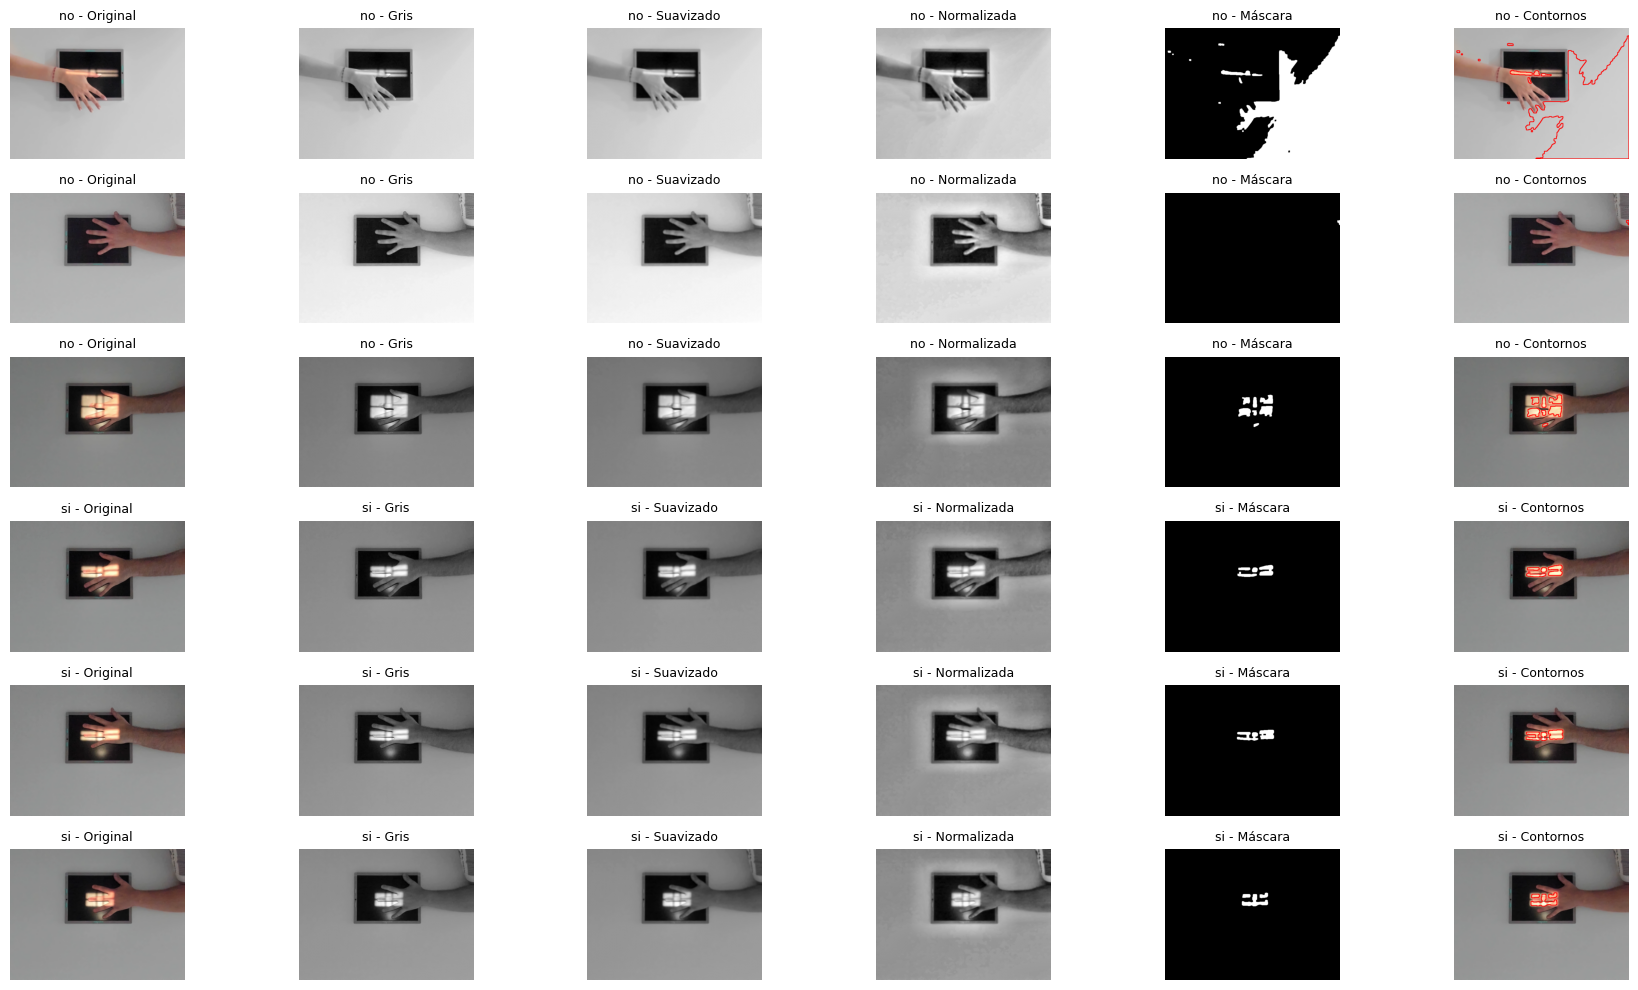

In [18]:
# Visualiza aquí el efecto de tu preprocesado sobre varios ejemplos.
muestra = df.groupby("etiqueta", group_keys=False).sample(
    n=3,
    random_state=SEED
)

plt.figure(figsize=(18, 10))

for i, (_, row) in enumerate(muestra.iterrows()):
    resultado = preprocesar_imagen(row["ruta"])

    if resultado is None:
        print("No se pudo leer:", row["ruta"])
        continue

    img_rgb = cv2.cvtColor(resultado["original"], cv2.COLOR_BGR2RGB)

    imagen_contornos = img_rgb.copy()
    cv2.drawContours(imagen_contornos, resultado["contornos"], -1, (255, 0, 0), 2)

    imagenes = [
        img_rgb,
        resultado["gray"],
        resultado["blur"],
        resultado["norm"],
        resultado["mask"],
        imagen_contornos
    ]

    titulos = [
        "Original",
        "Gris",
        "Suavizado",
        "Normalizada",
        "Máscara",
        "Contornos"
    ]

    for j, (imagen, titulo) in enumerate(zip(imagenes, titulos)):
        plt.subplot(len(muestra), 6, i * 6 + j + 1)
        plt.imshow(imagen, cmap="gray" if j in [1, 2, 3, 4] else None)
        plt.title(f"{row['etiqueta']} - {titulo}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Posible etapa 2: detectar la zona de luz

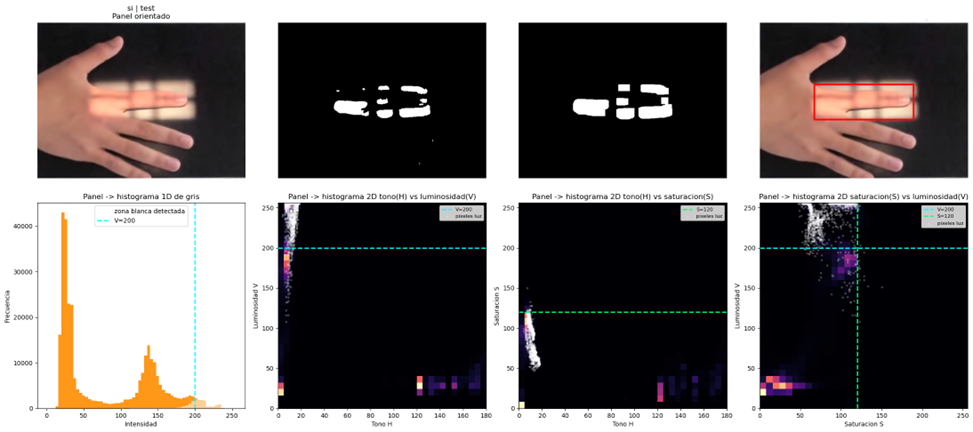

In [ ]:
# Detecta aquí una región relevante de la imagen.

In [ ]:
# Muestra aquí ejemplos de esa detección en imágenes si y no.

## Construir una regla de clasificación

Con la región relevante ya localizada, proponed una regla final.

Algunas ideas posibles:

- si el dedo invade demasiado una zona concreta, predecir `no`;
- si cierta región queda vacía o demasiado llena, predecir `no`;
- si una distancia o proporción geométrica supera un umbral, predecir `si` o `no`;
- combinar dos o tres reglas sencillas.

Lo importante es que podáis explicar por qué esa regla tiene sentido.

### Posible etapa 3: usar bordes o líneas como pista geométrica

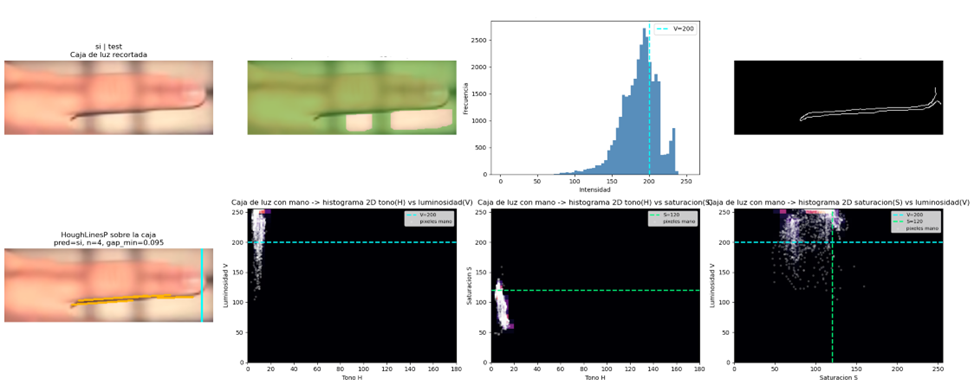

Esta imagen solo sugiere una posibilidad más: extraer bordes, buscar líneas o estudiar la geometría local del dedo dentro de una zona concreta.

In [ ]:
# Implementa aquí tu función de predicción para una imagen.

In [ ]:
# Aplica aquí tu regla a todas las imágenes de test.

## Evaluación

Calcula al menos:

- accuracy;
- precision;
- recall;
- F1;
- matriz de confusión.

Si queréis, podéis añadir también `balanced_accuracy`.

In [ ]:
# Calcula aquí las métricas de evaluación.

In [ ]:
# Dibuja aquí la matriz de confusión.

## Analizar errores

Esta es probablemente la parte más importante del día.

Buscad ejemplos donde el método falle y tratad de responder:

- ¿falla el preprocesado?
- ¿falla la detección de la región clave?
- ¿falla la regla final?
- ¿hay varios tipos de error distintos?

In [ ]:
# Selecciona aquí algunos errores y visualízalos.

## Conclusiones

Escribid aquí unas conclusiones breves:

- qué pipeline habéis probado;
- qué intuiciones han funcionado mejor;
- qué limitaciones habéis encontrado;